# Historical Parking Sensor EDA and IV Study-Area Matching

**Objective:** assess whether City of Melbourne historical parking sensor events can support treatment/control analysis for Infrastructure Victoria street segments.

This notebook deliberately separates:

- **Historical parking events**: arrival/departure records used to estimate occupancy over time.
- **Live parking sensors**: a current status snapshot, useful for current sensor coordinates but not a historical time series.
- **IV spatial files**: treatment/control locations and study-area polygons; these define *where* to analyse, not parking utilisation.

## 1. Load Dataset and Configure Paths

The notebook reads a bounded sample directly from the compressed City of Melbourne archive. This keeps Sprint 1 exploration reproducible without extracting a 2.35 GB CSV into the repository.

In [1]:
import re
import warnings
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore", message="GPKG: unrecognized user_version")

NOTEBOOK_NAME = "historical_parking_sensor_eda.ipynb"
project_candidates = [
    Path.cwd(),
    Path.cwd() / "Team Project",
    Path.home() / "Personal-Docs" / "Python" / "Sem 4" / "Team Project",
]
PROJECT_DIR = next(
    (path for path in project_candidates if (path / NOTEBOOK_NAME).is_file()),
    None,
)
if PROJECT_DIR is None:
    raise FileNotFoundError(f"Could not locate {NOTEBOOK_NAME}")

PARKING_DIR = PROJECT_DIR / "data" / "raw" / "parking"
IV_DIR = PROJECT_DIR / "data" / "raw" / "iv"
TABLE_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

street_candidates = [IV_DIR / "streets_spatial.gpkg", IV_DIR / "street_spatial.gpkg"]
STREET_PATH = next((path for path in street_candidates if path.exists()), street_candidates[0])
STUDY_AREA_PATH = IV_DIR / "street_spatial_study_area.gpkg"
PARKING_PATH = next(iter(sorted(PARKING_DIR.glob("*.zip"))), None)
SAMPLE_ROWS = 100_000

required_paths = [STREET_PATH, STUDY_AREA_PATH]
missing_files = [path.name for path in required_paths if not path.exists()]
if PARKING_PATH is None:
    missing_files.append("historical parking ZIP")
if missing_files:
    raise FileNotFoundError("Missing required inputs: " + ", ".join(missing_files))

print("All required input files are available.")

All required input files are available.


In [2]:
with zipfile.ZipFile(PARKING_PATH) as archive:
    csv_files = [
        file for file in archive.infolist()
        if file.filename.lower().endswith(".csv") and "__macosx" not in file.filename.lower()
    ]
    if not csv_files:
        raise ValueError(f"No CSV found inside {PARKING_PATH.name}")
    parking_csv = max(csv_files, key=lambda file: file.file_size)
    with archive.open(parking_csv) as source:
        parking_raw = pd.read_csv(source, nrows=SAMPLE_ROWS, low_memory=False)

print(f"Parking source: {PARKING_PATH.name}")
print(f"Parking rows loaded: {len(parking_raw):,}")

Parking source: on-street-car-parking-sensor-data-2020-jan-may.zip
Parking rows loaded: 100,000


## 2. Dataset Overview

Each row represents a completed parking event. The source provides arrival/departure timestamps, duration, bay and street identifiers, restriction details, and violation indicators.

In [3]:
overview = pd.Series(
    {
        "sample rows": f"{len(parking_raw):,}",
        "columns": parking_raw.shape[1],
        "unique streets": parking_raw["StreetName"].nunique(),
        "unique bays": parking_raw["BayId"].nunique(),
    },
    name="value",
).to_frame()

display(overview)
display(parking_raw.head())

,value
sample rows,"100,000"
columns,19
unique streets,42
unique bays,300


,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideName,BayId,InViolation,VehiclePresent
0,17811,04/28/2020 12:25:28 PM,04/28/2020 12:42:24 PM,17,1414E,60.0,2P MTR M-F 10:00-16:00,Rialto,839,KING STREET,528,COLLINS STREET,669,FLINDERS LANE,2,East,1200,0,0
1,18156,04/16/2020 09:58:18 PM,04/16/2020 10:48:27 PM,50,904E,NaN,NaN,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669,FLINDERS LANE,2,East,978,0,0
2,18156,04/19/2020 12:04:55 PM,04/19/2020 12:35:59 PM,31,904E,3.0,1P SUN 7:30-18:30,Degraves,627,ELIZABETH STREET,670,FLINDERS STREET,669,FLINDERS LANE,2,East,978,0,0
3,18289,05/24/2020 04:08:51 AM,05/24/2020 09:30:00 AM,322,437W,NaN,NaN,Windsor,647,EXHIBITION STREET,123,BOURKE STREET,911,LITTLE COLLINS STREET,5,West,702,0,0
4,18294,04/20/2020 07:01:36 AM,04/20/2020 07:01:44 AM,0,460E,NaN,NaN,Princes Theatre,647,EXHIBITION STREET,907,LITTLE BOURKE STREET,123,BOURKE STREET,2,East,708,0,0


## 3. Missing-Value Checks

Missing restriction fields are expected when no sign applied to an event. Missing identifiers, street names, or timestamps would directly affect matching and occupancy calculations.

In [4]:
missing_summary = pd.DataFrame(
    {
        "missing_count": parking_raw.isna().sum(),
        "missing_percent": (parking_raw.isna().mean() * 100).round(2),
    }
).sort_values("missing_percent", ascending=False)

display(missing_summary)
missing_summary.to_csv(TABLE_DIR / "parking_missing_values.csv")

,missing_count,missing_percent
SignPlateID,39823,39.82
Sign,39823,39.82
DeviceId,0,0.00
BetweenStreet1,0,0.00
InViolation,0,0.00
BayId,0,0.00
SideName,0,0.00
SideOfStreet,0,0.00
BetweenStreet2,0,0.00
BetweenStreet2ID,0,0.00


## 4. Duplicate Checks

Exact duplicates are removed before analysis. A second check uses bay, device, arrival, and departure fields to detect repeated representations of the same parking session.

In [5]:
session_key = ["DeviceId", "BayId", "ArrivalTime", "DepartureTime"]
exact_duplicate_count = int(parking_raw.duplicated().sum())
session_duplicate_count = int(parking_raw.duplicated(subset=session_key).sum())

duplicate_summary = pd.Series(
    {
        "exact duplicate rows": exact_duplicate_count,
        "duplicate session keys": session_duplicate_count,
    },
    name="count",
).to_frame()
display(duplicate_summary)

,count
exact duplicate rows,15
duplicate session keys,15


## 5. Timestamp Cleaning

Timestamps are parsed using the documented month/day/year format. Calculated interval length is used for analysis; duplicate session keys, negative intervals, and intervals longer than 24 hours are excluded as likely sensor anomalies.

In [6]:
parking = parking_raw.drop_duplicates(subset=session_key).copy()
timestamp_format = "%m/%d/%Y %I:%M:%S %p"
parking["arrival_time"] = pd.to_datetime(parking["ArrivalTime"], format=timestamp_format, errors="coerce")
parking["departure_time"] = pd.to_datetime(parking["DepartureTime"], format=timestamp_format, errors="coerce")
parking["calculated_duration_minutes"] = (
    parking["departure_time"] - parking["arrival_time"]
).dt.total_seconds() / 60

invalid_timestamp = parking[["arrival_time", "departure_time"]].isna().any(axis=1)
negative_interval = parking["calculated_duration_minutes"].lt(0)
over_24_hours = parking["calculated_duration_minutes"].gt(24 * 60)
clean_parking = parking.loc[~(invalid_timestamp | negative_interval | over_24_hours)].copy()

cleaning_summary = pd.Series(
    {
        "loaded sample rows": len(parking_raw),
        "duplicate session rows removed": session_duplicate_count,
        "unparseable timestamp rows removed": int(invalid_timestamp.sum()),
        "negative intervals removed": int(negative_interval.sum()),
        "intervals over 24 hours removed": int(over_24_hours.sum()),
        "clean rows retained": len(clean_parking),
    },
    name="count",
).to_frame()
date_coverage = pd.DataFrame(
    {
        "start": [clean_parking["arrival_time"].min()],
        "end": [clean_parking["departure_time"].max()],
        "days": [(clean_parking["departure_time"].max() - clean_parking["arrival_time"].min()).days + 1],
    },
    index=["observed sample coverage"],
)

display(cleaning_summary)
display(date_coverage)

,count
loaded sample rows,100000
duplicate session rows removed,15
unparseable timestamp rows removed,0
negative intervals removed,0
intervals over 24 hours removed,3
clean rows retained,99982


,start,end,days
observed sample coverage,2020-01-01,2020-05-26 10:23:10,147


## 6. Location and Street Analysis

Street names are standardized to uppercase and common suffixes are expanded (for example, `ST` to `STREET`). This supports a transparent first-pass match while retaining the original names for review.

,event_records
VehiclePresent,
1,51810
0,48172


,street_key,StreetName,event_records,unique_bays
23,KING STREET,KING STREET,37579,61
11,ELIZABETH STREET,ELIZABETH STREET,13010,7
3,BOURKE STREET,BOURKE STREET,11999,28
26,LITTLE COLLINS STREET,LITTLE COLLINS STREET,9934,23
12,EXHIBITION STREET,EXHIBITION STREET,7189,19
18,HARBOUR ESPLANADE,HARBOUR ESPLANADE,5072,23
25,LITTLE BOURKE STREET,LITTLE BOURKE STREET,2607,1
15,FLINDERS LANE,FLINDERS LANE,2577,6
36,SPENCER STREET,SPENCER STREET,2045,6
41,WILLIAM STREET,WILLIAM STREET,2043,10


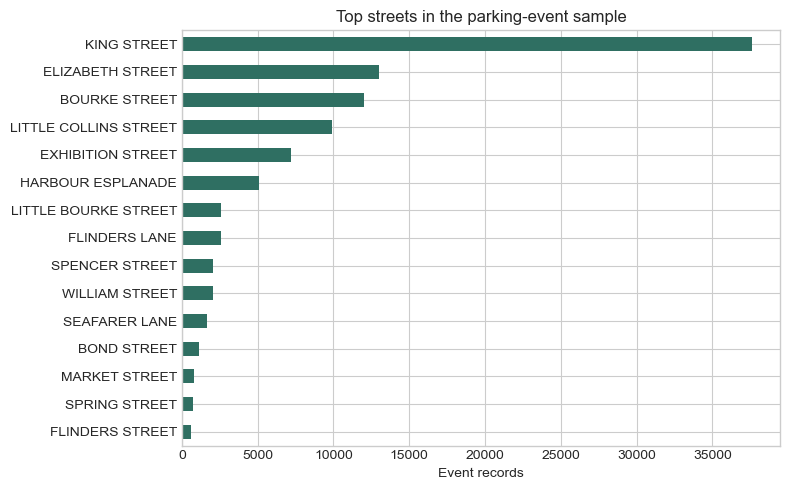

In [7]:
street_suffixes = {
    "ST": "STREET", "RD": "ROAD", "AVE": "AVENUE",
    "HWY": "HIGHWAY", "PDE": "PARADE", "LN": "LANE",
    "DR": "DRIVE", "BLVD": "BOULEVARD", "CRES": "CRESCENT",
}

def normalize_street_name(value: object) -> str:
    words = re.sub(r"[^A-Z0-9 ]+", " ", str(value).upper()).split()
    return " ".join(street_suffixes.get(word, word) for word in words)

clean_parking["street_key"] = clean_parking["StreetName"].map(normalize_street_name)
street_summary = (
    clean_parking.groupby(["street_key", "StreetName"], as_index=False)
    .agg(event_records=("BayId", "size"), unique_bays=("BayId", "nunique"))
    .sort_values("event_records", ascending=False)
)

display(clean_parking["VehiclePresent"].value_counts().rename("event_records").to_frame())
display(street_summary.head(15))

top_streets = street_summary.head(15).sort_values("event_records")
ax = top_streets.plot.barh(
    x="StreetName", y="event_records", figsize=(8, 5), legend=False, color="#2f6f62"
 )
ax.set(title="Top streets in the parking-event sample", xlabel="Event records", ylabel="")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "parking_events_by_street.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. IV Spatial-File Loading

The base segment file is the study ground truth. The buffered polygons define the wider parking study areas. Both use `street_segment_id` and EPSG:7899.

In [8]:
streets = gpd.read_file(STREET_PATH)
study_areas = gpd.read_file(STUDY_AREA_PATH)
streets["street_key"] = streets["street_name"].map(normalize_street_name)

iv_overview = pd.DataFrame(
    {
        "rows": [len(streets), len(study_areas)],
        "unique_segment_ids": [streets["street_segment_id"].nunique(), study_areas["street_segment_id"].nunique()],
        "invalid_geometries": [(~streets.geometry.is_valid).sum(), (~study_areas.geometry.is_valid).sum()],
        "crs": [str(streets.crs), str(study_areas.crs)],
    },
    index=["IV street segments", "IV study areas"],
)
display(iv_overview)

,rows,unique_segment_ids,invalid_geometries,crs
IV street segments,315,315,0,EPSG:7899
IV study areas,316,316,0,EPSG:7899


## 8. Spatial and Street Matching

The historical event archive has street and bay identifiers but no coordinates. Therefore, this Sprint 1 prototype matches normalized street names to IV segments. The study-area polygons are retained for a later point-in-polygon match if a historical bay-coordinate crosswalk becomes available.

In [9]:
streets["street_segment_id"] = pd.to_numeric(streets["street_segment_id"], errors="coerce").astype("Int64")
parking_street_keys = set(clean_parking["street_key"])
iv_street_keys = set(streets["street_key"])

streets["match_status"] = np.where(streets["street_key"].isin(parking_street_keys), "matched", "unmatched")
streets["scope"] = np.where(streets["lga"].eq("Melbourne (C)"), "City of Melbourne", "Other LGA")
clean_parking["iv_name_match"] = clean_parking["street_key"].isin(iv_street_keys)

all_counts = streets["match_status"].value_counts()
melbourne_counts = streets.loc[streets["scope"].eq("City of Melbourne"), "match_status"].value_counts()
match_summary = pd.DataFrame(
    {
        "matched": [all_counts.get("matched", 0), melbourne_counts.get("matched", 0)],
        "unmatched": [all_counts.get("unmatched", 0), melbourne_counts.get("unmatched", 0)],
    },
    index=["All IV segments", "City of Melbourne only"],
)
match_summary["matched_percent"] = (
    match_summary["matched"] / match_summary[["matched", "unmatched"]].sum(axis=1) * 100
).round(1)

display(match_summary)
print(f"Parking event records matched by street name: {clean_parking['iv_name_match'].mean() * 100:.1f}%")

street_match_table = streets.drop(columns="geometry").sort_values(
    ["scope", "match_status", "street_name", "street_segment_id"]
)
street_match_table.to_csv(TABLE_DIR / "matched_vs_unmatched_iv_segments.csv", index=False)

,matched,unmatched,matched_percent
All IV segments,50,265,15.9
City of Melbourne only,43,40,51.8


Parking event records matched by street name: 36.9%


## 9. Coverage Analysis

Coverage is reported for every IV segment using observed dates, event counts, and bay counts. Because this Sprint 1 match is street-name based, IV segments on the same street share the same parking coverage.

In [10]:
parking_coverage = (
    clean_parking.groupby("street_key", as_index=False)
    .agg(
        parking_event_records=("BayId", "size"),
        occupied_event_records=("VehiclePresent", "sum"),
        unique_bays=("BayId", "nunique"),
        parking_coverage_start=("arrival_time", "min"),
        parking_coverage_end=("departure_time", "max"),
    )
)

segment_coverage = streets.drop(columns="geometry").merge(
    parking_coverage, on="street_key", how="left"
)
count_columns = ["parking_event_records", "occupied_event_records", "unique_bays"]
segment_coverage[count_columns] = segment_coverage[count_columns].fillna(0).astype(int)
segment_coverage["parking_coverage_days"] = (
    segment_coverage["parking_coverage_end"] - segment_coverage["parking_coverage_start"]
).dt.days.add(1)

coverage_columns = [
    "street_segment_id", "street_name", "suburb", "lga",
    "treatment_or_control", "intervention_type", "match_status",
    "parking_event_records", "occupied_event_records", "unique_bays",
    "parking_coverage_start", "parking_coverage_end", "parking_coverage_days",
]
coverage_table = segment_coverage[coverage_columns]
coverage_table.to_csv(TABLE_DIR / "street_date_coverage.csv", index=False)
display(
    coverage_table.loc[segment_coverage["scope"].eq("City of Melbourne")]
    .sort_values(["match_status", "parking_event_records"], ascending=[True, False])
    .head(20)
)

,street_segment_id,street_name,suburb,lga,treatment_or_control,intervention_type,match_status,parking_event_records,occupied_event_records,unique_bays,parking_coverage_start,parking_coverage_end,parking_coverage_days
194,12026,BOURKE ST,Melbourne,Melbourne (C),control,control,matched,11999,6337,28,2020-01-01 00:00:00,2020-05-26 07:30:00,147.0
195,12027,BOURKE ST,Melbourne,Melbourne (C),control,control,matched,11999,6337,28,2020-01-01 00:00:00,2020-05-26 07:30:00,147.0
196,12028,BOURKE ST,Melbourne,Melbourne (C),control,control,matched,11999,6337,28,2020-01-01 00:00:00,2020-05-26 07:30:00,147.0
263,7325,EXHIBITION STREET,Melbourne,Melbourne (C),treatment,protected bike lane,matched,7189,3636,19,2020-01-01 00:00:00,2020-05-26 10:19:11,147.0
264,7326,EXHIBITION STREET,Melbourne,Melbourne (C),treatment,protected bike lane,matched,7189,3636,19,2020-01-01 00:00:00,2020-05-26 10:19:11,147.0
265,7327,EXHIBITION STREET,Melbourne,Melbourne (C),treatment,protected bike lane,matched,7189,3636,19,2020-01-01 00:00:00,2020-05-26 10:19:11,147.0
118,5458,SPENCER STREET,Docklands,Melbourne (C),control,control,matched,2045,1047,6,2020-03-13 05:06:32,2020-04-02 14:00:54,21.0
119,5459,SPENCER STREET,Melbourne,Melbourne (C),control,control,matched,2045,1047,6,2020-03-13 05:06:32,2020-04-02 14:00:54,21.0
284,11077,WILLIAM STREET,Melbourne,Melbourne (C),treatment,protected bike lane,matched,2043,1028,10,2020-01-18 07:30:00,2020-05-10 20:00:41,114.0
285,11078,WILLIAM STREET,Melbourne,Melbourne (C),treatment,protected bike lane,matched,2043,1028,10,2020-01-18 07:30:00,2020-05-10 20:00:41,114.0


## 10. Hourly Occupancy Prototype

Each valid matched interval is split at hour boundaries. Hourly occupancy is calculated as occupied sensor-minutes divided by all observed sensor-minutes. This avoids treating periods with no sensor observations as known vacancies.

,street_key,hour,occupied_minutes,observed_minutes,observed_bays,occupancy_rate
0,ALBERT STREET,2020-04-08 12:00:00,49.650000,49.650000,1,1.0
1,ALBERT STREET,2020-04-08 13:00:00,60.000000,60.000000,1,1.0
2,ALBERT STREET,2020-04-08 14:00:00,28.683333,28.683333,1,1.0
3,ALBERT STREET,2020-05-13 17:00:00,0.533333,0.533333,1,1.0
4,ALBERT STREET,2020-05-23 07:00:00,10.833333,10.833333,1,1.0
5,ALBERT STREET,2020-05-23 18:00:00,39.616667,39.616667,1,1.0
6,ALBERT STREET,2020-05-23 19:00:00,60.000000,60.000000,1,1.0
7,ALBERT STREET,2020-05-23 20:00:00,60.000000,60.000000,1,1.0
8,ALBERT STREET,2020-05-23 21:00:00,60.000000,60.000000,1,1.0
9,ALBERT STREET,2020-05-23 22:00:00,60.000000,60.000000,1,1.0


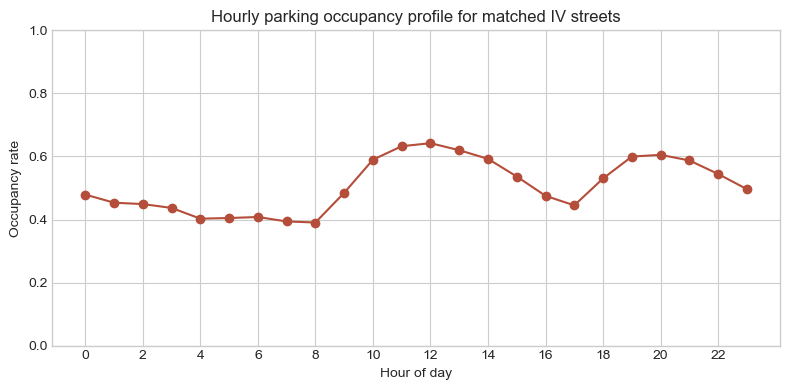

In [11]:
hourly_events = clean_parking.loc[
    clean_parking["iv_name_match"] & clean_parking["calculated_duration_minutes"].gt(0),
    ["street_key", "BayId", "VehiclePresent", "arrival_time", "departure_time"],
].reset_index(drop=True)

hourly_events["start_hour"] = hourly_events["arrival_time"].dt.floor("h")
hourly_events["end_hour"] = (hourly_events["departure_time"] - pd.Timedelta(microseconds=1)).dt.floor("h")
hour_count = (
    (hourly_events["end_hour"] - hourly_events["start_hour"]).dt.total_seconds() // 3600 + 1
).astype(int)

hourly_parts = hourly_events.loc[hourly_events.index.repeat(hour_count)].copy()
hour_offset = hourly_parts.groupby(level=0).cumcount()
hourly_parts["hour"] = hourly_parts["start_hour"] + pd.to_timedelta(hour_offset, unit="h")
hourly_parts["hour_end"] = hourly_parts["hour"] + pd.Timedelta(hours=1)
hourly_parts["interval_start"] = hourly_parts[["arrival_time", "hour"]].max(axis=1)
hourly_parts["interval_end"] = hourly_parts[["departure_time", "hour_end"]].min(axis=1)
hourly_parts["observed_minutes"] = (
    hourly_parts["interval_end"] - hourly_parts["interval_start"]
).dt.total_seconds() / 60
hourly_parts["occupied_minutes"] = hourly_parts["observed_minutes"].where(
    hourly_parts["VehiclePresent"].eq(1), 0
)

bay_hour = (
    hourly_parts.groupby(["street_key", "BayId", "hour"], as_index=False)
    .agg(observed_minutes=("observed_minutes", "sum"), occupied_minutes=("occupied_minutes", "sum"))
)
bay_hour["observed_minutes"] = bay_hour["observed_minutes"].clip(upper=60)
bay_hour["occupied_minutes"] = np.minimum(bay_hour["occupied_minutes"], bay_hour["observed_minutes"])

hourly_occupancy = (
    bay_hour.groupby(["street_key", "hour"], as_index=False)
    .agg(
        occupied_minutes=("occupied_minutes", "sum"),
        observed_minutes=("observed_minutes", "sum"),
        observed_bays=("BayId", "nunique"),
    )
)
hourly_occupancy["occupancy_rate"] = hourly_occupancy["occupied_minutes"] / hourly_occupancy["observed_minutes"]
hourly_occupancy.to_csv(TABLE_DIR / "hourly_occupancy_prototype.csv", index=False)

hourly_profile = (
    hourly_occupancy.assign(hour_of_day=hourly_occupancy["hour"].dt.hour)
    .groupby("hour_of_day", as_index=False)[["occupied_minutes", "observed_minutes"]].sum()
)
hourly_profile["occupancy_rate"] = hourly_profile["occupied_minutes"] / hourly_profile["observed_minutes"]

display(hourly_occupancy.head(10))
ax = hourly_profile.plot(
    x="hour_of_day", y="occupancy_rate", marker="o", color="#b44d3a",
    figsize=(8, 4), legend=False,
 )
ax.set(
    title="Hourly parking occupancy profile for matched IV streets",
    xlabel="Hour of day", ylabel="Occupancy rate", xticks=range(0, 24, 2), ylim=(0, 1),
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hourly_occupancy_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Findings and Limitations

### Findings

- The sample contains **100,000 rows, 19 columns, 42 streets, and 300 bays**, covering **1 January to 26 May 2020**.
- Street, bay, and timestamp fields are complete. `Sign` and `SignPlateID` are missing for **39.82%** of rows but are not needed for this prototype.
- Cleaning removed **15 duplicate sessions** and **3 intervals longer than 24 hours**, retaining **99,982 records**.
- Both IV files use EPSG:7899 and valid geometry. The base file has **315 segments** and the study-area file has **316 polygons**.
- Normalized names matched **43 of 83 (51.8%)** City of Melbourne IV segments. **36.9%** of sampled parking records occur on a matched IV street.
- The hourly prototype calculates occupied minutes as a share of observed sensor-minutes.

### Assumptions

- `VehiclePresent = 1` means occupied and `VehiclePresent = 0` means vacant.
- Common street suffixes are standardized, but fuzzy matching is not used.
- Intervals longer than 24 hours are treated as sensor anomalies.

### Limitations and Next Steps

- The first 100,000 rows are a bounded, non-random sample. Final estimates should process the full archive or use a documented sampling method.
- January-May 2020 includes COVID-19 disruption and predates many 2021 interventions, so this notebook does not claim a causal before/after result.
- Historical events have no coordinates. Name matching cannot distinguish multiple IV segments on the same street; a historical bay-coordinate crosswalk is needed for precise spatial matching.
- The study-area file contains one additional segment ID that should be reconciled before a final point-in-polygon workflow.
- Occupancy uses observed sensor-minutes and does not yet adjust for outages, changing sensor inventory, parking restrictions, or public holidays.

### Conclusion

This Sprint 1 analysis confirms that the historical parking sensor dataset can support part of Team B's parking-utilisation analysis, particularly for City of Melbourne locations. However, coverage is incomplete across the IV study sites, and street-name matching alone cannot uniquely identify individual street segments. The next step is to improve spatial matching using historical bay coordinates, process a larger portion of the archive, and validate the hourly occupancy method before conducting pre/post-intervention comparisons.

### Generated Outputs

- `outputs/tables/parking_missing_values.csv`
- `outputs/tables/matched_vs_unmatched_iv_segments.csv`
- `outputs/tables/street_date_coverage.csv`
- `outputs/tables/hourly_occupancy_prototype.csv`
- `outputs/figures/parking_events_by_street.png`
- `outputs/figures/hourly_occupancy_profile.png`